# MonReader
## Introduction
**Background:**
- Our company develops innovative Artificial Intelligence and Computer Vision solutions that revolutionize industries. Machines that can see: We pack our solutions in small yet intelligent devices that can be easily integrated to your existing data flow. Computer vision for everyone: Our devices can recognize faces, estimate age and gender, classify clothing types and colors, identify everyday objects and detect motion. Technical consultancy: We help you identify use cases of artificial intelligence and computer vision in your industry. Artificial intelligence is the technology of today, not the future.

- MonReader is a new mobile document digitization experience for the blind, for researchers and for everyone else in need of fully automatic, very fast and high-quality document scanning in bulk. It is composed of a mobile app and all the user needs to do is flip pages and everything is handled by MonReader: it detects page flips from low-resolution camera preview and takes a high-resolution picture of the document, recognizing its corners and crops it accordingly, and it dewarps the cropped document to obtain a bird's eye view, sharpens the contrast between the text and the background and finally recognizes the text with formatting kept intact, being further corrected by MonReader's ML powered redactor.

**Data Description:**
- We collected page flipping video from smart phones and labelled them as flipping and not flipping.
- We clipped the videos as short videos and labelled them as flipping or not flipping. The extracted frames are then saved to disk in a sequential order with the following naming structure: VideoID_FrameNumber

**Download Data:**
- https://drive.google.com/file/d/1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm/view?usp=sharing

**Goal(s):**
- Predict if the page is being flipped using a single image.

**Success Metrics:**
- Evaluate model performance based on F1 score, the higher the better.

**Bonus(es):**
- Predict if a given sequence of images contains an action of flipping.

### Libraries

In [1]:
# Warnings imports
from warnings import filterwarnings
filterwarnings("ignore")

# Pandas configuration
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

# Basic imports
import math
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Sklearn imports
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Tensorflow imports
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential

### Helper function(s)

In [2]:
def print_bold(text):
    """Print ``text`` to stdout with ANSI bold formatting."""
    print(f"\033[1m{text}\033[0;0m")

## Dataset

### Load images

In [3]:
img_height, img_width, img_channels = 180, 180, 3
batch_size = 32
data_dir = "../images/training"
test_data_dir = "../images/testing"
loading_dataset_seed = 0

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=loading_dataset_seed,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 2402 files belonging to 2 classes.
Using 1922 files for training.


In [5]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=loading_dataset_seed,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 2402 files belonging to 2 classes.
Using 480 files for validation.


In [6]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    seed=loading_dataset_seed,
    image_size=(img_height, img_width),
    batch_size=batch_size)

Found 597 files belonging to 2 classes.


In [7]:
# Shape of training data
for image_batch, labels_batch in train_ds.take(1):
    print(image_batch.shape)
    print(labels_batch.shape)

(32, 180, 180, 3)
(32,)


In [8]:
classes_names = train_ds.class_names
print(classes_names)

['flip', 'notflip']


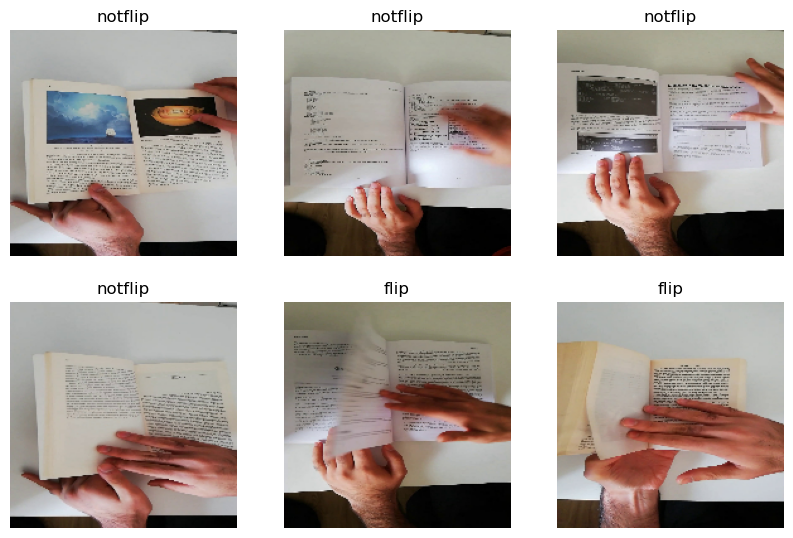

In [9]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classes_names[labels[i]])
        plt.axis("off")

plt.show()

In [10]:
def evaluate_model(model, test_data):
    results = {}    
    predicted_labels = []
    true_labels = []
    all_images = []
    for images, labels in test_data:
        true_labels.extend(labels.numpy())
        predicted_labels.extend(tf.argmax(model.predict(images), axis=1).numpy())
    # Accuracy
    results["accuracy"] = accuracy_score(true_labels, predicted_labels)
    # F1 Score
    results["f1_score"] = f1_score(true_labels, predicted_labels)
    cm = confusion_matrix(true_labels, predicted_labels)
    class_names = test_data.class_names
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()
    return results

## Models

### Custom

In [11]:
custom_model = models.Sequential([
    layers.Input(shape=(img_height, img_width, img_channels)),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(classes_names), activation="softmax"),
])

custom_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [12]:
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 178, 178, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 89, 89, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 87, 87, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 43, 43, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 59168)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       3,786,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,797,090 (14.48 MB)

 Trainable params: 3,797,090 (14.48 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
custom_model_history = custom_model.fit(train_ds, validation_data=val_ds, epochs=7)

Epoch 1/7
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 285ms/step - accuracy: 0.6644 - loss: 25.4054 - val_accuracy: 0.8562 - val_loss: 0.3234
Epoch 2/7
61/61 ━━━━━━━━━━━━━━━━━━━━ 17s 280ms/step - accuracy: 0.8923 - loss: 0.2574 - val_accuracy: 0.9500 - val_loss: 0.1289
Epoch 3/7
61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.9579 - loss: 0.1019 - val_accuracy: 0.9688 - val_loss: 0.0777
Epoch 4/7
61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.9860 - loss: 0.0378 - val_accuracy: 0.9688 - val_loss: 0.1111
Epoch 5/7
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 250ms/step - accuracy: 0.9917 - loss: 0.0277 - val_accuracy: 0.9854 - val_loss: 0.0652
Epoch 6/7
61/61 ━━━━━━━━━━━━━━━━━━━━ 17s 276ms/step - accuracy: 0.9797 - loss: 0.0681 - val_accuracy: 0.9729 - val_loss: 0.0453
Epoch 7/7
61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.9974 - loss: 0.0173 - val_accuracy: 0.9979 - val_loss: 0.0125


#### Evaluating The Model

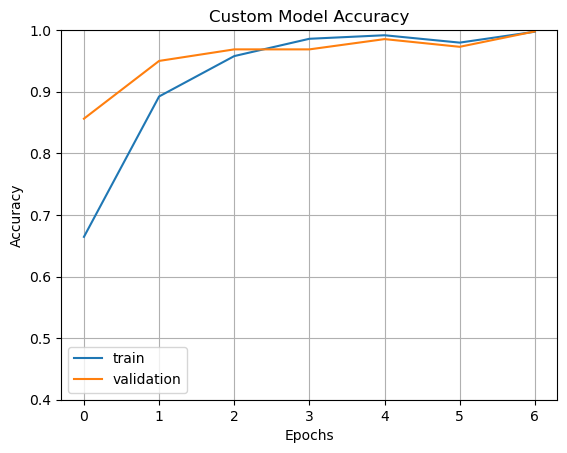

In [14]:
fig1 = plt.gcf()
plt.plot(custom_model_history.history["accuracy"])
plt.plot(custom_model_history.history["val_accuracy"])
plt.axis(ymin=0.4, ymax=1)
plt.grid()
plt.title("Custom Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend(["train", "validation"])
plt.show()

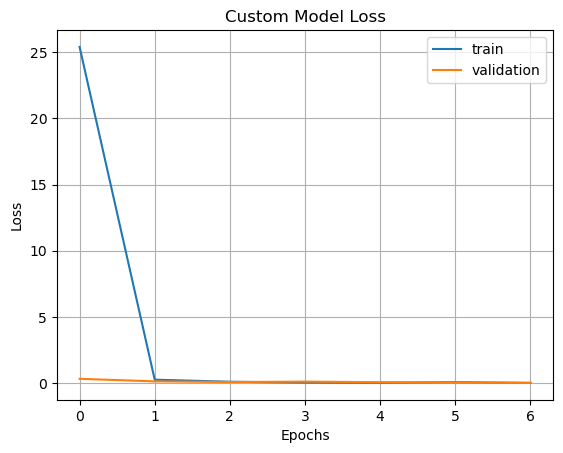

In [15]:
plt.plot(custom_model_history.history["loss"])
plt.plot(custom_model_history.history["val_loss"])
plt.grid()
plt.title("Custom Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend(["train", "validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


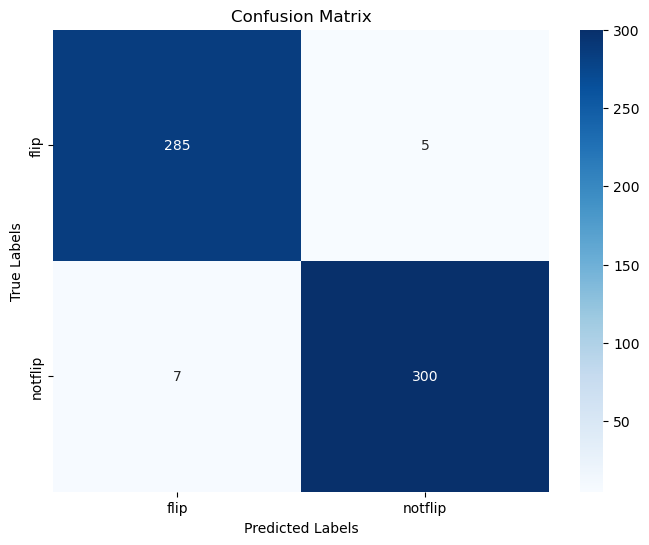

In [16]:
custom_model_evaluation = evaluate_model(custom_model, test_ds)

#### Save Model

In [17]:
custom_model_path = "../models/custom_model.keras"
custom_model.save(custom_model_path)
custom_model_size = os.path.getsize(custom_model_path) / (1024 * 1024)
print(f"Model size: {custom_model_size:.2f} MB")

Model size: 43.49 MB


### ResNet

In [18]:
resnet_backbone = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(img_height, img_width, img_channels),
    pooling="avg",
    weights="imagenet",
)
resnet_backbone.trainable = False

resnet_model = Sequential([
    resnet_backbone,
    layers.Dense(512, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    layers.Dense(len(classes_names), activation="softmax"),
])
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [19]:
resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2048)                │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,637,826 (93.99 MB)

 Trainable params: 1,050,114 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [20]:
resnet_model_history = resnet_model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7997 - loss: 5.0491 - val_accuracy: 0.8854 - val_loss: 2.4395
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9464 - loss: 1.6933 - val_accuracy: 0.9167 - val_loss: 1.2392
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9625 - loss: 0.9510 - val_accuracy: 0.7333 - val_loss: 1.1633
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8861 - loss: 0.9201 - val_accuracy: 0.9333 - val_loss: 0.7031
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9698 - loss: 0.5149 - val_accuracy: 0.9500 - val_loss: 0.4662


#### Evaluating The Model

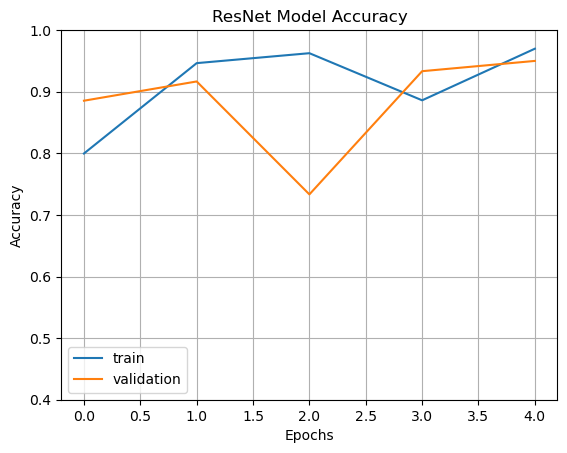

In [21]:
fig1 = plt.gcf()
plt.plot(resnet_model_history.history["accuracy"])
plt.plot(resnet_model_history.history["val_accuracy"])
plt.axis(ymin=0.4, ymax=1)
plt.grid()
plt.title("ResNet Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend(["train", "validation"])
plt.show()

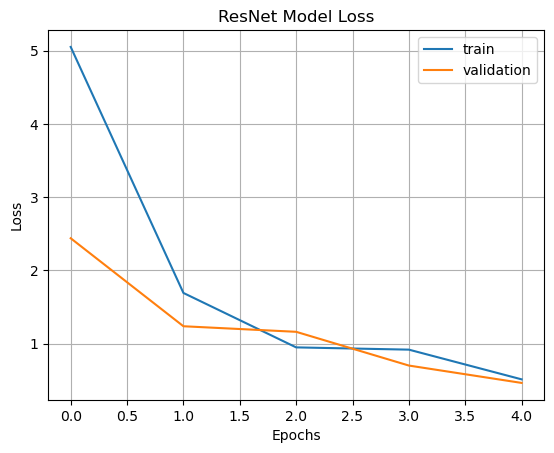

In [22]:
plt.plot(resnet_model_history.history["loss"])
plt.plot(resnet_model_history.history["val_loss"])
plt.grid()
plt.title("ResNet Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend(["train", "validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 861ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 892ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 832ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 989ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 966ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 941ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


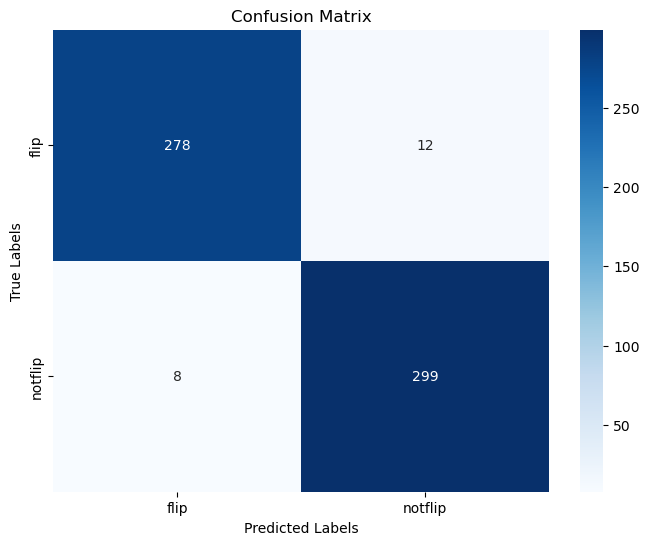

In [23]:
resnet_model_evaluation = evaluate_model(resnet_model, test_ds)

#### Save model

In [24]:
resnet_model_path = "../models/resnet_model.weights.h5"
resnet_model.save_weights(resnet_model_path)

resnet_model_size = os.path.getsize(resnet_model_path)/(1024*1024)
print(f"Model size: {resnet_model_size:.2f} MB")

Model size: 102.46 MB


### MobileNet

In [25]:
mobilenet_backbone = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(img_height, img_width, img_channels),
    pooling="avg",
    weights="imagenet",
)
mobilenet_backbone.trainable = False

mobilenet_model = Sequential([
    mobilenet_backbone,
    layers.Dense(512, activation="relu"),
    layers.Dense(len(classes_names), activation="softmax"),
])
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [26]:
mobilenet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         655,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,914,882 (11.12 MB)

 Trainable params: 656,898 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
mobilenet_model_history = mobilenet_model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 37s 515ms/step - accuracy: 0.6790 - loss: 0.7825 - val_accuracy: 0.7354 - val_loss: 0.4969
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 33s 540ms/step - accuracy: 0.8002 - loss: 0.4527 - val_accuracy: 0.8250 - val_loss: 0.3690
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 36s 581ms/step - accuracy: 0.8502 - loss: 0.3367 - val_accuracy: 0.9208 - val_loss: 0.2353
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 31s 508ms/step - accuracy: 0.9110 - loss: 0.2444 - val_accuracy: 0.9000 - val_loss: 0.2420
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 476ms/step - accuracy: 0.9422 - loss: 0.1755 - val_accuracy: 0.9271 - val_loss: 0.1902
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 471ms/step - accuracy: 0.9651 - loss: 0.1295 - val_accuracy: 0.9646 - val_loss: 0.1279
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 487ms/step - accuracy: 0.9594 - loss: 0.1288 - val_accuracy: 0.9646 - val_loss: 0.1138
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 478ms/step - accuracy: 0.9755 - loss: 0.0918 - val_accu

#### Evaluating The Model

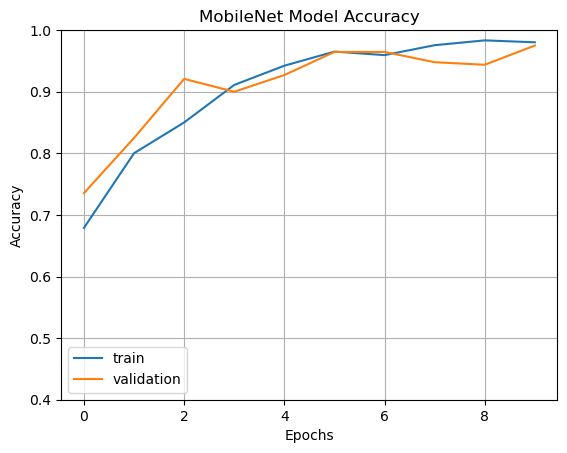

In [28]:
fig1 = plt.gcf()
plt.plot(mobilenet_model_history.history["accuracy"])
plt.plot(mobilenet_model_history.history["val_accuracy"])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title("MobileNet Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend(["train", "validation"])
plt.show()

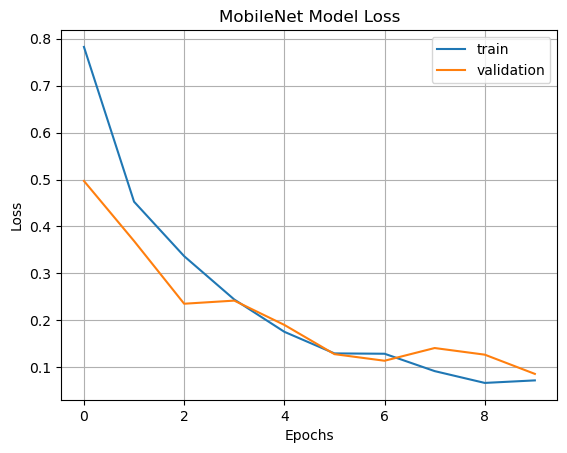

In [29]:
plt.plot(mobilenet_model_history.history["loss"])
plt.plot(mobilenet_model_history.history["val_loss"])
plt.grid()
plt.title("MobileNet Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend(["train", "validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


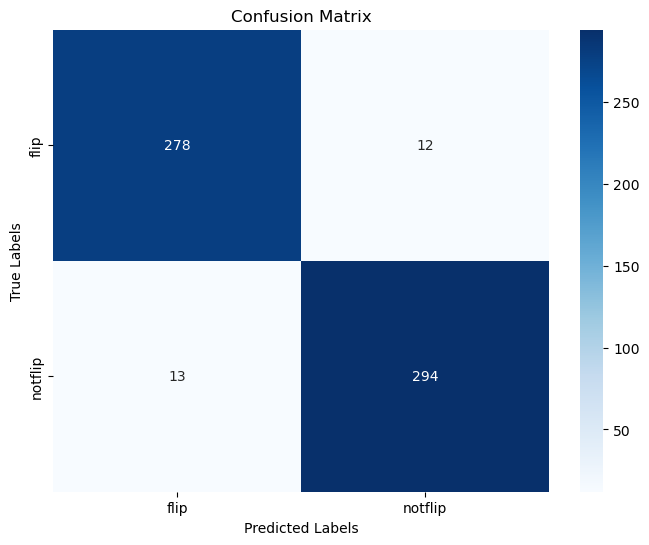

In [30]:
mobilenet_model_evaluation = evaluate_model(mobilenet_model, test_ds)

#### Save Model

In [31]:
mobilenet_model_path = "../models/mobilenet_model.weights.h5"
mobilenet_model.save_weights(mobilenet_model_path)
mobilenet_model_size = os.path.getsize(mobilenet_model_path)/(1024*1024)
print(f"Model size: {mobilenet_model_size:.2f} MB")

Model size: 16.54 MB


### Final model collation

In [32]:
values = {"accuracy":[custom_model_evaluation["accuracy"],
                      resnet_model_evaluation["accuracy"],
                      mobilenet_model_evaluation["accuracy"]],
          "f1_score":[custom_model_evaluation["f1_score"],
                      resnet_model_evaluation["f1_score"],
                      mobilenet_model_evaluation["f1_score"]],
          "model size":[np.round(custom_model_size, 2),
                        np.round(resnet_model_size, 2),
                        np.round(mobilenet_model_size, 2)]}

df = pd.DataFrame(values, index=["custom_model", "resnet", "mobilenet"])
df

,accuracy,f1_score,model size
custom_model,0.979899,0.980392,43.49
resnet,0.966499,0.967638,102.46
mobilenet,0.958124,0.959217,16.54


**Observations:**
- All three models exceed 95% test accuracy and F1, so the page-flip task is well-served by any of them.
- The simple custom CNN narrowly wins on F1 (~0.9804) on this train/test split.
- ResNet50 is a close second (F1 ≈ 0.9676) but is by far the largest model (~102 MB).
- MobileNetV2 trails on F1 by ~2 percentage points (F1 ≈ 0.9592) but is the smallest model (~17 MB), so it is the most attractive choice for on-device deployment in a mobile-app setting like MonReader. We use it for the per-image error analysis that follows.

## Post analysis
- Here we will plot and analyze the incorrectly classified images from the test dataset.

In [33]:
X = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    seed=loading_dataset_seed,
    image_size=(img_height, img_width),
    batch_size=1)

Found 597 files belonging to 2 classes.


In [34]:
X.class_names

['flip', 'notflip']

In [35]:
images = []
labels = []
for image, label in X:
    images.append(image)
    labels.append(label.numpy()[0])
labels = np.array(labels)

In [36]:
all_images = tf.concat(images, axis=0)
predictions = tf.argmax(mobilenet_model.predict(all_images, verbose=0), axis=1).numpy()

In [37]:
mask = labels != predictions
mask.sum(), len(mask), mask.sum() / len(mask)

(np.int64(25), 597, np.float64(0.04187604690117253))

**NOTE:**
- We re-imported the test data.
- We noted that the class names are as we expect.
- MobileNetV2 incorrectly predicted 25 out of 597 images on the held-out test set, i.e. **~95.8% accuracy** (F1 ≈ 0.9592).
- We will now **plot the incorrectly classified images** to see if any insight can be gleaned as to why.

### Sample plot

INCORRECT MODEL PREDICTIONS:


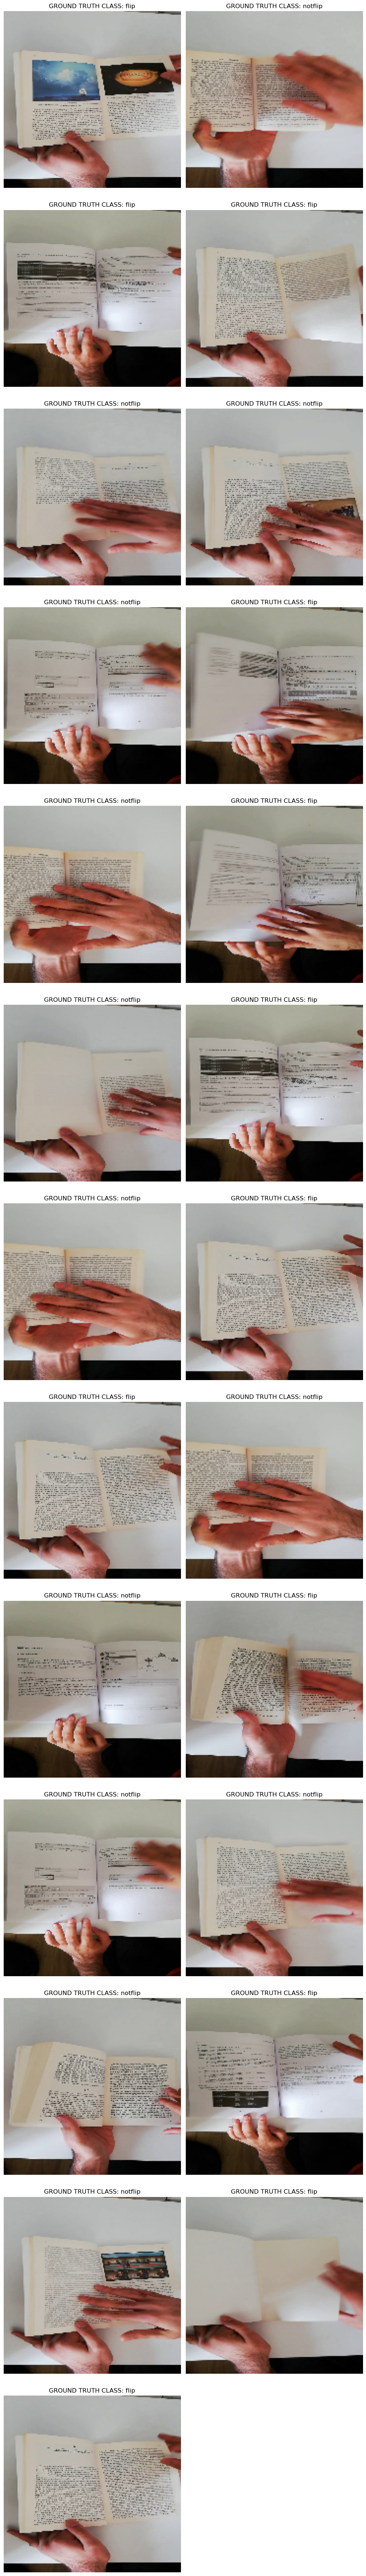

In [38]:
images_wrongly_predicted = np.array(images)[mask]
labels_wrongly_predicted = np.array(labels)[mask]
rows = math.ceil(len(images_wrongly_predicted)/2)
index = range(1, len(images_wrongly_predicted)+1)
plt.figure(figsize=(10, 70))
print_bold("INCORRECT MODEL PREDICTIONS:")

for i, image, label in zip(index, images_wrongly_predicted, labels_wrongly_predicted):
    ax = plt.subplot(rows, 2, i)
    plt.imshow(image[0].astype("uint8"))
    plt.title(f"GROUND TRUTH CLASS: {classes_names[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**NOTE:**
- As noted above, MobileNetV2's accuracy of around 95.8% on the test set is strong, and within ~2 percentage points of the custom CNN (F1 ≈ 0.9804) and ResNet50 (F1 ≈ 0.9676).
- For the misclassified images, there are many potential reasons for their misclassification, including:
    - Low quality/resolution image
    - Difficult to interpret image
    - Ambiguous labelling of image